In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import urllib.parse
import re
import math

In [5]:
# ============================================================
# PART 1 — EMAIL DATASET CLEANING
# ============================================================
ceas = pd.read_csv("CEAS_08.csv")
nazario = pd.read_csv("Nazario.csv")
nigerian = pd.read_csv("Nigerian_Fraud.csv")
ling = pd.read_csv("Ling.csv")

df_email = pd.concat([ceas, nazario, nigerian, ling], ignore_index=True)
df_email = df_email[['subject', 'body', 'label']]

# Combine subject + body
df_email['text'] = df_email['subject'].fillna('') + ' ' + df_email['body'].fillna('')

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)               # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)      # Remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)     # Remove special characters
    text = text.lower().strip()
    return text

df_email['text'] = df_email['text'].apply(clean_text)
df_email = df_email[df_email['text'].str.strip() != '']
df_email = df_email.dropna(subset=['text', 'label'])

print("EMAIL DATASET READY")
print(df_email.shape)
print(df_email['label'].value_counts())

# ============================================================
# PART 2 — URL DATASET CLEANING
# ============================================================
df_url = pd.read_csv("phishing_site_urls.csv")

print("\n✅ URL DATASET LOADED")
print(df_url.shape)
print(df_url.head())
print(df_url.columns.tolist())
print(df_url.iloc[:, -1].value_counts())  

EMAIL DATASET READY
(46910, 4)
label
1    27197
0    19713
Name: count, dtype: int64

✅ URL DATASET LOADED
(549346, 2)
                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3  mail.printakid.com/www.online.americanexpress....   bad
4  thewhiskeydregs.com/wp-content/themes/widescre...   bad
['URL', 'Label']
Label
good    392924
bad     156422
Name: count, dtype: int64


In [6]:
# ============================================================
# URL DATASET CLEANING
# ============================================================

# Convert labels to numbers
df_url['label'] = df_url['Label'].map({'bad': 1, 'good': 0})

# Drop original Label column
df_url = df_url.drop(columns=['Label'])

# Check for nulls
df_url = df_url.dropna()

# Dataset is large (549k) — sample it to keep things manageable
df_url_phishing = df_url[df_url['label'] == 1]          # all 156k bad
df_url_legit = df_url[df_url['label'] == 0].sample(n=156422, random_state=42)  # match bad count

# Combine balanced dataset
df_url_clean = pd.concat([df_url_phishing, df_url_legit], ignore_index=True)
df_url_clean = df_url_clean.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("✅ URL DATASET CLEANED & BALANCED")
print(df_url_clean.shape)
print(df_url_clean['label'].value_counts())
print(df_url_clean.head())

# ============================================================
# SAVE BOTH CLEAN DATASETS
# ============================================================

df_email.to_csv("email_clean.csv", index=False)
df_url_clean.to_csv("url_clean.csv", index=False)

print("\n✅ Both datasets saved!")
print("📁 email_clean.csv")
print("📁 url_clean.csv")

✅ URL DATASET CLEANED & BALANCED
(312844, 2)
label
0    156422
1    156422
Name: count, dtype: int64
                                                 URL  label
0  wiki.worldflicks.org/salaberry-de-valleyfield....      0
1                          imdb.com/title/tt0376290/      0
2  freepages.genealogy.rootsweb.ancestry.com/~ess...      0
3  answers.yahoo.com/question/index?qid=200806242...      0
4       law.duke.edu/shell/cite.pl?56+Duke+L.+J.+545      0

✅ Both datasets saved!
📁 email_clean.csv
📁 url_clean.csv


In [7]:
df_email = pd.read_csv("email_clean.csv")
df_email = df_email.dropna(subset=['text', 'label'])
df_url = pd.read_csv("url_clean.csv")

In [8]:
# ============================================================
# PART 1 — EMAIL FEATURE EXTRACTION (TF-IDF)
# ============================================================
# TF-IDF on email text
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_email = TfidfVectorizer(max_features=5000)
X_email = tfidf_email.fit_transform(df_email['text'])
y_email = df_email['label'].values

X_email_train, X_email_test, y_email_train, y_email_test = train_test_split(
    X_email, y_email, test_size=0.2, random_state=42
)
print("✅ EMAIL FEATURES READY")
print(f"Train: {X_email_train.shape} | Test: {X_email_test.shape}")

✅ EMAIL FEATURES READY
Train: (37528, 5000) | Test: (9382, 5000)


In [9]:
# ============================================================
# PART 2 — URL FEATURE EXTRACTION
# ============================================================
def extract_url_features(url):
    url = str(url)
    try:
        parsed = urllib.parse.urlparse(url if url.startswith('http') else 'http://' + url)
        domain = parsed.netloc
        path = parsed.path
    except:
        domain, path = url, ''

    # Calculate URL entropy
    def entropy(s):
        prob = [s.count(c) / len(s) for c in set(s)]
        return -sum(p * math.log2(p) for p in prob) if s else 0

    return {
        'url_length'       : len(url),
        'domain_length'    : len(domain),
        'num_subdomains'   : domain.count('.'),
        'has_ip'           : 1 if re.match(r'\d+\.\d+\.\d+\.\d+', domain) else 0,
        'has_at'           : 1 if '@' in url else 0,
        'has_https'        : 1 if url.startswith('https') else 0,
        'num_special_chars': sum(url.count(c) for c in ['-', '_', '=', '?', '&']),
        'path_length'      : len(path),
        'entropy'          : round(entropy(url), 4),
        'num_digits'       : sum(c.isdigit() for c in url),
    }

# Extract features for all URLs
url_features = df_url['URL'].apply(extract_url_features)
X_url = pd.DataFrame(list(url_features))
y_url = df_url['label'].values
# Split into train/test
X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    X_url, y_url, test_size=0.2, random_state=42
)
print("\n URL FEATURES READY")
print(f"Train: {X_url_train.shape} | Test: {X_url_test.shape}")
print(X_url.head())


 URL FEATURES READY
Train: (250275, 10) | Test: (62569, 10)
   url_length  domain_length  num_subdomains  has_ip  has_at  has_https  \
0          50             20               2       0       0          0   
1          25              8               1       0       0          0   
2         104             41               4       0       0          0   
3          58             17               2       0       0          0   
4          44             12               2       0       0          0   

   num_special_chars  path_length  entropy  num_digits  
0                  2           30   4.2055           0  
1                  0           17   3.8937           7  
2                  0           63   4.2939           0  
3                  2           15   4.7177          16  
4                  1           14   4.2156           5  


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ============================================================
# PART 1 — EMAIL MODELS
# ============================================================

print("=" * 50)
print("📧 EMAIL CLASSIFICATION MODELS")
print("=" * 50)

# Logistic Regression - Email
lr_email = LogisticRegression(max_iter=1000)
lr_email.fit(X_email_train, y_email_train)
lr_email_pred = lr_email.predict(X_email_test)

print("\n📊 Logistic Regression - Email")
print(f"Accuracy: {accuracy_score(y_email_test, lr_email_pred):.4f}")
print(classification_report(y_email_test, lr_email_pred, target_names=['Legitimate', 'Phishing']))

# Random Forest - Email
rf_email = RandomForestClassifier(n_estimators=100, random_state=42)
rf_email.fit(X_email_train, y_email_train)
rf_email_pred = rf_email.predict(X_email_test)

print("\n📊 Random Forest - Email")
print(f"Accuracy: {accuracy_score(y_email_test, rf_email_pred):.4f}")
print(classification_report(y_email_test, rf_email_pred, target_names=['Legitimate', 'Phishing']))

# ============================================================
# PART 2 — URL MODELS
# ============================================================

print("=" * 50)
print("🔗 URL CLASSIFICATION MODELS")
print("=" * 50)

# Logistic Regression - URL
lr_url = LogisticRegression(max_iter=1000)
lr_url.fit(X_url_train, y_url_train)
lr_url_pred = lr_url.predict(X_url_test)

print("\n📊 Logistic Regression - URL")
print(f"Accuracy: {accuracy_score(y_url_test, lr_url_pred):.4f}")
print(classification_report(y_url_test, lr_url_pred, target_names=['Legitimate', 'Phishing']))

# Random Forest - URL
rf_url = RandomForestClassifier(n_estimators=100, random_state=42)
rf_url.fit(X_url_train, y_url_train)
rf_url_pred = rf_url.predict(X_url_test)

print("\n📊 Random Forest - URL")
print(f"Accuracy: {accuracy_score(y_url_test, rf_url_pred):.4f}")
print(classification_report(y_url_test, rf_url_pred, target_names=['Legitimate', 'Phishing']))

# ============================================================
# PART 3 — SAVE RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 50)
print("📋 FINAL SUMMARY")
print("=" * 50)
print(f"Email - Logistic Regression Accuracy : {accuracy_score(y_email_test, lr_email_pred):.4f}")
print(f"Email - Random Forest Accuracy        : {accuracy_score(y_email_test, rf_email_pred):.4f}")
print(f"URL   - Logistic Regression Accuracy  : {accuracy_score(y_url_test, lr_url_pred):.4f}")
print(f"URL   - Random Forest Accuracy        : {accuracy_score(y_url_test, rf_url_pred):.4f}")

📧 EMAIL CLASSIFICATION MODELS

📊 Logistic Regression - Email
Accuracy: 0.9887
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      3889
    Phishing       0.99      0.99      0.99      5493

    accuracy                           0.99      9382
   macro avg       0.99      0.99      0.99      9382
weighted avg       0.99      0.99      0.99      9382


📊 Random Forest - Email
Accuracy: 0.9886
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3889
    Phishing       0.99      0.99      0.99      5493

    accuracy                           0.99      9382
   macro avg       0.99      0.99      0.99      9382
weighted avg       0.99      0.99      0.99      9382

🔗 URL CLASSIFICATION MODELS

📊 Logistic Regression - URL
Accuracy: 0.6558
              precision    recall  f1-score   support

  Legitimate       0.63      0.73      0.68     31167
    Phishing       0.69      0.58      0.63

In [12]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

print("⏳ Downloading BERT model from HuggingFace...")

# Download pre-trained BERT tokenizer and model
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2  # 2 classes: phishing and legitimate
)

print("✅ BERT model downloaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model_bert.parameters()):,}")

C:\Users\Shazana Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Downloading BERT model from HuggingFace...


C:\Users\Shazana Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shazana Khan\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|█████████████████████████████████████████████████████████████

✅ BERT model downloaded successfully!
Model parameters: 109,483,778


In [ ]:
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ============================================================
# STEP 3 — PREPARE DATA
# ============================================================

df_email = pd.read_csv("email_clean.csv").dropna(subset=['text', 'label'])
df_sample = df_email.sample(n=5000, random_state=42).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_sample['text'].tolist(),
    df_sample['label'].tolist(),
    test_size=0.2, random_state=42
)

print(f"✅ Train: {len(X_train)} | Test: {len(X_test)}")

# Tokenize
def tokenize(texts, labels):
    encodings = tokenizer_bert(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    )
    return encodings, torch.tensor(labels)

train_encodings, train_labels = tokenize(X_train, y_train)
test_encodings,  test_labels  = tokenize(X_test,  y_test)
print("✅ Data tokenized!")

# ============================================================
# STEP 4 — FINE-TUNE BERT
# ============================================================

train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    train_labels
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

model_bert = model_bert.to(device)
optimizer  = AdamW(model_bert.parameters(), lr=2e-5)

model_bert.train()
for epoch in range(3):
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()
        outputs = model_bert(input_ids=input_ids,
                             attention_mask=attention_mask,
                             labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Progress update every 50 batches
        if (i + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1}/3 complete — Avg Loss: {avg_loss:.4f}")

print("\n✅ BERT Fine-tuning Complete!")

# ============================================================
# STEP 5 — EVALUATE
# ============================================================

model_bert.eval()
test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    test_labels
)
test_loader = DataLoader(test_dataset, batch_size=8)

all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

print("\n✅ BERT EMAIL MODEL RESULTS")
print(f"Accuracy: {accuracy_score(y_test, all_preds):.4f}")
print(classification_report(y_test, all_preds,
      target_names=['Legitimate', 'Phishing']))

# Save
model_bert.save_pretrained("bert_phishing_model")
tokenizer_bert.save_pretrained("bert_phishing_model")
print("\n📁 BERT model saved in bert_phishing_model/")

In [14]:
from transformers import pipeline

print("⏳ Downloading pre-trained phishing detection model...")

# Load already fine-tuned phishing detection model
phishing_pipeline = pipeline(
    "text-classification",
    model="cybersectony/phishing-email-detection-distilbert_v2.4.1"
)

print("✅ Model downloaded and ready!")

# Test it immediately
test_emails = [
    "Congratulations! Your account has been selected. Click here to claim your prize now!",
    "Hi team, please find attached the meeting notes from yesterday's standup.",
    "URGENT: Your bank account will be suspended. Verify your details immediately.",
    "The project deadline has been moved to next Friday. Please update your tasks."
]

print("\n🔍 Testing on sample emails:")
print("-" * 60)
for email in test_emails:
    result = phishing_pipeline(email)[0]
    label  = result['label']
    score  = result['score']
    icon   = "🔴 PHISHING" if "phishing" in label.lower() or label == "LABEL_1" else "🟢 LEGITIMATE"
    print(f"{icon} (confidence: {score:.2%})")
    print(f"   Email: {email[:60]}...")
    print()

⏳ Downloading pre-trained phishing detection model...


C:\Users\Shazana Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shazana Khan\.cache\huggingface\hub\models--cybersectony--phishing-email-detection-distilbert_v2.4.1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████████████████

✅ Model downloaded and ready!

🔍 Testing on sample emails:
------------------------------------------------------------
🔴 PHISHING (confidence: 100.00%)
   Email: Congratulations! Your account has been selected. Click here ...

🟢 LEGITIMATE (confidence: 100.00%)
   Email: Hi team, please find attached the meeting notes from yesterd...

🔴 PHISHING (confidence: 100.00%)
   Email: URGENT: Your bank account will be suspended. Verify your det...

🟢 LEGITIMATE (confidence: 99.99%)
   Email: The project deadline has been moved to next Friday. Please u...



In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

df_email = pd.read_csv("email_clean.csv").dropna(subset=['text', 'label'])

# Use 500 samples for evaluation (pipeline is slow on CPU for large data)
df_eval = df_email.sample(n=500, random_state=42).reset_index(drop=True)

print("⏳ Evaluating on 500 real emails...")

# Run predictions in batches
predictions = []
batch_size  = 32

for i in tqdm(range(0, len(df_eval), batch_size)):
    batch = df_eval['text'][i:i+batch_size].tolist()
    results = phishing_pipeline(batch, truncation=True, max_length=128)
    for r in results:
        label = r['label']
        pred  = 1 if 'phishing' in label.lower() or label == 'LABEL_1' else 0
        predictions.append(pred)

y_true = df_eval['label'].tolist()

print("\n✅ BERT PRE-TRAINED MODEL RESULTS")
print(f"Accuracy: {accuracy_score(y_true, predictions):.4f}")
print(classification_report(y_true, predictions,
      target_names=['Legitimate', 'Phishing']))
# Fix - just save the predictions correctly
df_eval['bert_prediction'] = predictions
df_eval.to_csv("bert_predictions.csv", index=False)
print("📁 Predictions saved to bert_predictions.csv")

⏳ Evaluating on 500 real emails...


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:29<00:00,  1.85s/it]


✅ BERT PRE-TRAINED MODEL RESULTS
Accuracy: 0.8740
              precision    recall  f1-score   support

  Legitimate       0.87      0.82      0.84       204
    Phishing       0.88      0.91      0.90       296

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500

📁 Predictions saved to bert_predictions.csv


In [17]:
import pandas as pd
import re
from sklearn.metrics import accuracy_score

df_email = pd.read_csv("email_clean.csv").dropna(subset=['text', 'label'])
phishing_emails = df_email[df_email['label'] == 1].sample(n=200, random_state=42).reset_index(drop=True)

# ============================================================
# ADVERSARIAL ATTACK TECHNIQUES
# ============================================================

def attack_char_substitution(text):
    """Replace letters with similar looking characters"""
    text = text.replace('a', '@').replace('o', '0')
    text = text.replace('i', '1').replace('e', '3')
    text = text.replace('s', '$').replace('l', '1')
    return text

def attack_add_spaces(text):
    """Add spaces between characters to break keyword detection"""
    words = text.split()
    spaced = [' '.join(list(w)) if len(w) > 4 else w for w in words]
    return ' '.join(spaced)

def attack_repeated_chars(text):
    """Add repeated characters to confuse models"""
    words = text.split()
    modified = [w[0] + w + w[-1] if len(w) > 3 else w for w in words]
    return ' '.join(modified)

def attack_mixed_case(text):
    """Alternate upper and lower case"""
    return ''.join(c.upper() if i % 2 == 0 else c.lower()
                   for i, c in enumerate(text))

# ============================================================
# APPLY ATTACKS & EVALUATE
# ============================================================

attacks = {
    'Original'          : lambda x: x,
    'Char Substitution' : attack_char_substitution,
    'Add Spaces'        : attack_add_spaces,
    'Repeated Chars'    : attack_repeated_chars,
    'Mixed Case'        : attack_mixed_case,
}

print("🔍 ADVERSARIAL TESTING RESULTS")
print("=" * 55)
print(f"{'Attack Type':<25} {'Detected':>10} {'Missed':>10} {'Detection Rate':>15}")
print("-" * 55)

results = {}
for attack_name, attack_fn in attacks.items():
    # Apply attack
    modified_texts = phishing_emails['text'].apply(attack_fn).tolist()

    # Test with BERT pipeline
    preds = []
    for i in range(0, len(modified_texts), 32):
        batch   = modified_texts[i:i+32]
        outputs = phishing_pipeline(batch, truncation=True, max_length=128)
        for r in outputs:
            pred = 1 if 'phishing' in r['label'].lower() or r['label'] == 'LABEL_1' else 0
            preds.append(pred)

    detected = sum(preds)
    missed   = len(preds) - detected
    rate     = detected / len(preds) * 100
    results[attack_name] = rate

    print(f"{attack_name:<25} {detected:>10} {missed:>10} {rate:>14.1f}%")

print("=" * 55)

# ============================================================
# SUMMARY
# ============================================================

print("\n📊 ROBUSTNESS SUMMARY")
print("-" * 40)
for attack, rate in results.items():
    bar    = "█" * int(rate / 5)
    status = "✅ Robust" if rate >= 80 else "⚠️ Vulnerable" if rate >= 60 else "❌ Weak"
    print(f"{attack:<25} {rate:>5.1f}% {status}")

print(f"\n🎯 Average Detection Rate: {sum(results.values())/len(results):.1f}%")
print("\n📁 Saving adversarial results...")

# Save results
df_results = pd.DataFrame(list(results.items()), columns=['Attack', 'Detection_Rate'])
df_results.to_csv("adversarial_results.csv", index=False)
print("✅ Saved to adversarial_results.csv")

🔍 ADVERSARIAL TESTING RESULTS
Attack Type                 Detected     Missed  Detection Rate
-------------------------------------------------------
Original                         172         28           86.0%
Char Substitution                198          2           99.0%
Add Spaces                       200          0          100.0%
Repeated Chars                   172         28           86.0%
Mixed Case                       172         28           86.0%

📊 ROBUSTNESS SUMMARY
----------------------------------------
Original                   86.0% ✅ Robust
Char Substitution          99.0% ✅ Robust
Add Spaces                100.0% ✅ Robust
Repeated Chars             86.0% ✅ Robust
Mixed Case                 86.0% ✅ Robust

🎯 Average Detection Rate: 91.4%

📁 Saving adversarial results...
✅ Saved to adversarial_results.csv


✅ Pipeline trained! Accuracy: 0.9650

🔴 TOP PHISHING WORDS:
your       5.340145
love       2.700052
you        2.555682
watches    2.208850
replica    2.134386
our        2.066283
money      1.864656
account    1.815594
health     1.655362
men        1.613172
my         1.582595
top        1.524860
will       1.512836
life       1.483400
he         1.468617

🟢 TOP LEGITIMATE WORDS:
wrote        -3.080016
the          -2.628264
list         -2.087825
re           -1.872414
on           -1.870366
university   -1.864227
if           -1.716175
2007         -1.711172
is           -1.687465
at           -1.670721
opensuse     -1.607366
im           -1.583617
but          -1.533609
language     -1.501901
perl         -1.412962


C:\Users\Shazana Khan\AppData\Local\Temp\ipykernel_740\1749215692.py:69: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Shazana Khan\AppData\Local\Temp\ipykernel_740\1749215692.py:69: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Shazana Khan\AppData\Local\Temp\ipykernel_740\1749215692.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("explainable_ai.png", dpi=150, bbox_inches='tight')
C:\Users\Shazana Khan\AppData\Local\Temp\ipykernel_740\1749215692.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("explainable_ai.png", dpi=150, bbox_inches='tight')
C:\Users\Shazana Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  f

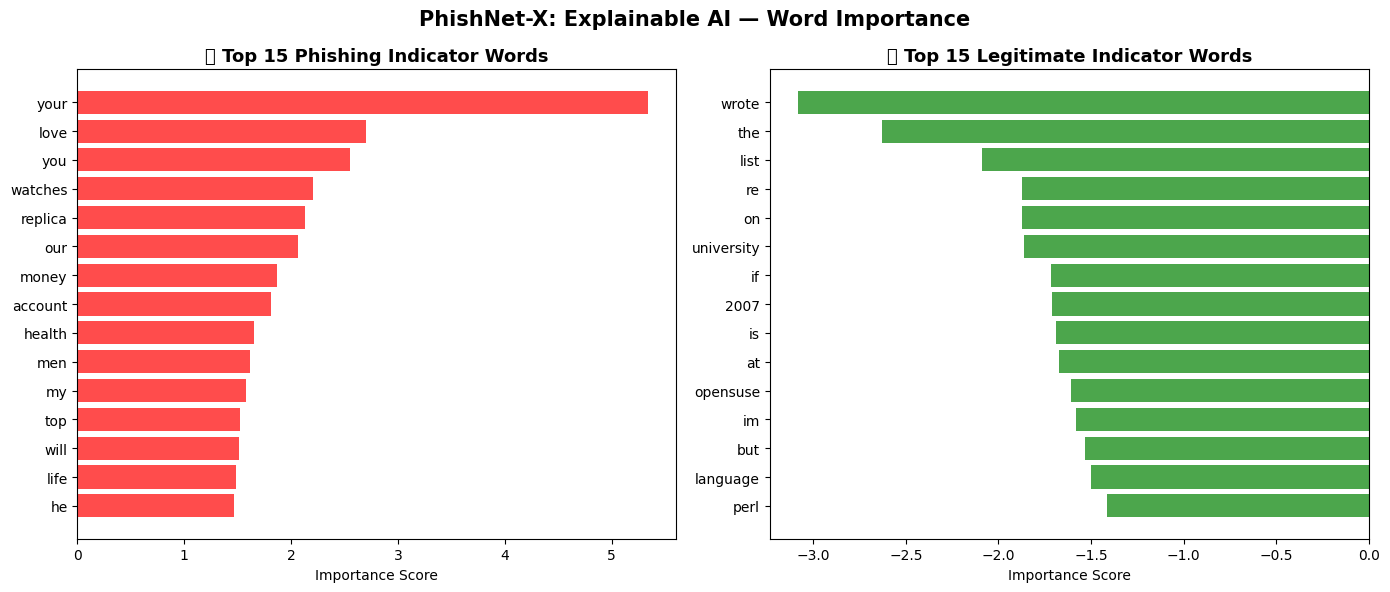


📁 Chart saved as explainable_ai.png

📧 Sample Email: Urgent: Your account will be suspended. Click here to verify your details immediately!
🎯 Prediction : 🔴 PHISHING
📊 Confidence : Phishing=97.71% | Legitimate=2.29%

🔍 Word-level Explanation:
-----------------------------------
  your            score:  5.3401  🔴 Phishing
  account         score:  1.8156  🔴 Phishing
  will            score:  1.5128  🔴 Phishing
  here            score:  0.9409  🔴 Phishing
  click           score:  0.3636  🔴 Phishing
  details         score:  0.1462  🔴 Phishing
  verify          score:  0.1254  🔴 Phishing
  be              score: -0.4461  🟢 Legit
  to              score: -0.7811  🟢 Legit


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import shap

# ============================================================
# BUILD SIMPLE PIPELINE FOR EXPLAINABILITY
# (SHAP works best with sklearn models)
# ============================================================

df_email = pd.read_csv("email_clean.csv").dropna(subset=['text', 'label'])
df_sample = df_email.sample(n=3000, random_state=42).reset_index(drop=True)

# Build pipeline
pipeline_xai = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000)),
    ('clf',   LogisticRegression(max_iter=1000))
])

from sklearn.model_selection import train_test_split
X_train_xai, X_test_xai, y_train_xai, y_test_xai = train_test_split(
    df_sample['text'], df_sample['label'],
    test_size=0.2, random_state=42
)

pipeline_xai.fit(X_train_xai, y_train_xai)
print(f"✅ Pipeline trained! Accuracy: {pipeline_xai.score(X_test_xai, y_test_xai):.4f}")

# ============================================================
# SHAP EXPLAINER
# ============================================================

# Get feature names and coefficients
feature_names = pipeline_xai.named_steps['tfidf'].get_feature_names_out()
coefficients  = pipeline_xai.named_steps['clf'].coef_[0]

# Top phishing and legitimate words
top_phishing  = pd.Series(coefficients, index=feature_names).nlargest(15)
top_legit     = pd.Series(coefficients, index=feature_names).nsmallest(15)

print("\n🔴 TOP PHISHING WORDS:")
print(top_phishing.to_string())

print("\n🟢 TOP LEGITIMATE WORDS:")
print(top_legit.to_string())

# ============================================================
# VISUALIZE — TOP PHISHING vs LEGITIMATE WORDS
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Phishing words
ax1.barh(top_phishing.index[::-1], top_phishing.values[::-1], color='red', alpha=0.7)
ax1.set_title('🔴 Top 15 Phishing Indicator Words', fontsize=13, fontweight='bold')
ax1.set_xlabel('Importance Score')
ax1.axvline(x=0, color='black', linewidth=0.5)

# Legitimate words
ax2.barh(top_legit.index[::-1], top_legit.values[::-1], color='green', alpha=0.7)
ax2.set_title('🟢 Top 15 Legitimate Indicator Words', fontsize=13, fontweight='bold')
ax2.set_xlabel('Importance Score')
ax2.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('PhishNet-X: Explainable AI — Word Importance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("explainable_ai.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n📁 Chart saved as explainable_ai.png")

# ============================================================
# EXPLAIN A SINGLE EMAIL
# ============================================================

sample_email = "Urgent: Your account will be suspended. Click here to verify your details immediately!"
sample_clean = sample_email.lower()

proba = pipeline_xai.predict_proba([sample_clean])[0]
pred  = "🔴 PHISHING" if proba[1] > 0.5 else "🟢 LEGITIMATE"

print(f"\n📧 Sample Email: {sample_email}")
print(f"🎯 Prediction : {pred}")
print(f"📊 Confidence : Phishing={proba[1]:.2%} | Legitimate={proba[0]:.2%}")

# Show which words triggered it
tfidf      = pipeline_xai.named_steps['tfidf']
clf        = pipeline_xai.named_steps['clf']
vec        = tfidf.transform([sample_clean])
word_scores = {}

for word in sample_clean.split():
    if word in feature_names:
        idx   = list(feature_names).index(word)
        score = coefficients[idx]
        word_scores[word] = round(score, 4)

print("\n🔍 Word-level Explanation:")
print("-" * 35)
for word, score in sorted(word_scores.items(), key=lambda x: x[1], reverse=True):
    indicator = "🔴 Phishing" if score > 0 else "🟢 Legit"
    print(f"  {word:<15} score: {score:>7.4f}  {indicator}")